### Import and Create Environment Instance

In [1]:
import numpy as np
import pandas as pd
import timeit
import sys
from functools import partial
from copy import deepcopy
# Add measurement mcts python package to path
sys.path.append('src/measurement_mcts')
from measurement_mcts.mcts.mcts import mcts_with_rollout, get_best_trajectory, MCTSNode, DummyNode, get_action_subtree
from measurement_mcts.mcts.tree_viz import render_pyvis
from measurement_mcts.state_evaluation.reinforcement_learning import MCTSRLWrapper, plot_state_image
from measurement_mcts.environment.measurement_control_env import MeasurementControlEnvironment

# Create the environment
env = MeasurementControlEnvironment(init_reset=False)

/home/austin/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Toy Measurement Control Initialized


### Reset to get Random Object Configuration

In [2]:
env.reset();

### Load State

In [3]:
env.load_state('state_configurations', 'evaluation1')

### Save State

In [4]:
env.save_state('state_configurations', 'evaluation1')

### Draw and Get Starting State

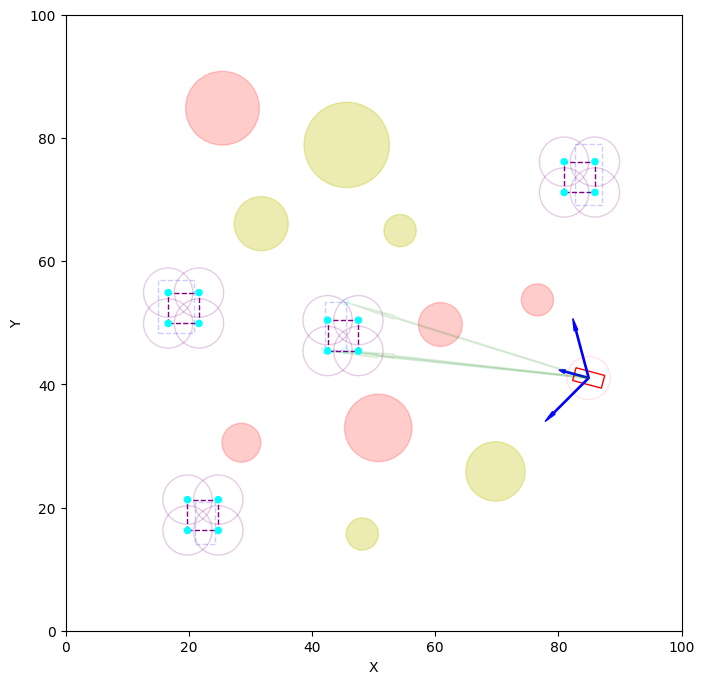

In [3]:
env.draw_state(env.get_state())
starting_state = env.get_state()

### Parameters

In [4]:
learning_iterations = 30
explore_factor = 0.1
discount_factor = 1.0
rollout_method = 'random_same'

### MCTS Methods Definition

# Test One Search

/home/austin/MeasurementMCTS/src/measurement_mcts/measurement_mcts/mcts/mcts.py:221: RuntimeWarning: divide by zero encountered in log
  * np.sqrt(np.log(self.number_visits)


Time taken:  0.3666968759989686


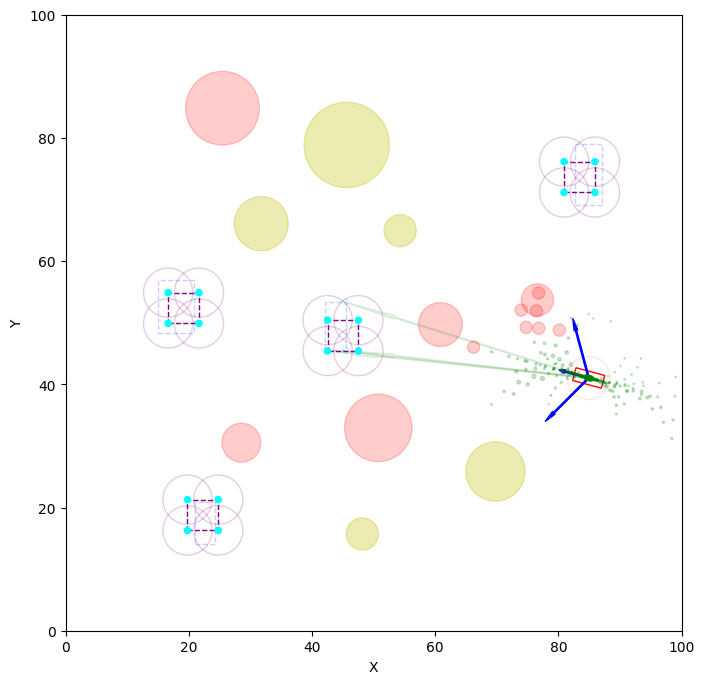

In [6]:
start_time = timeit.default_timer()
root = mcts_with_rollout(starting_state, learning_iterations, explore_factor, discount_factor, rollout_method)
print("Time taken: ", timeit.default_timer() - start_time)

# Display the tree and state
render_pyvis(root, env.action_space, show_unsimulated=False)
env.draw_state(starting_state, root_node=root, scaling=4, bias=0.1, max=1., rew=True)

In [7]:
# Test tree reuse

subroot = get_action_subtree(root, root.best_child())

render_pyvis(subroot, env.action_space, show_unsimulated=False, filename='tree_reuse')

Time taken:  0.36099171200112323


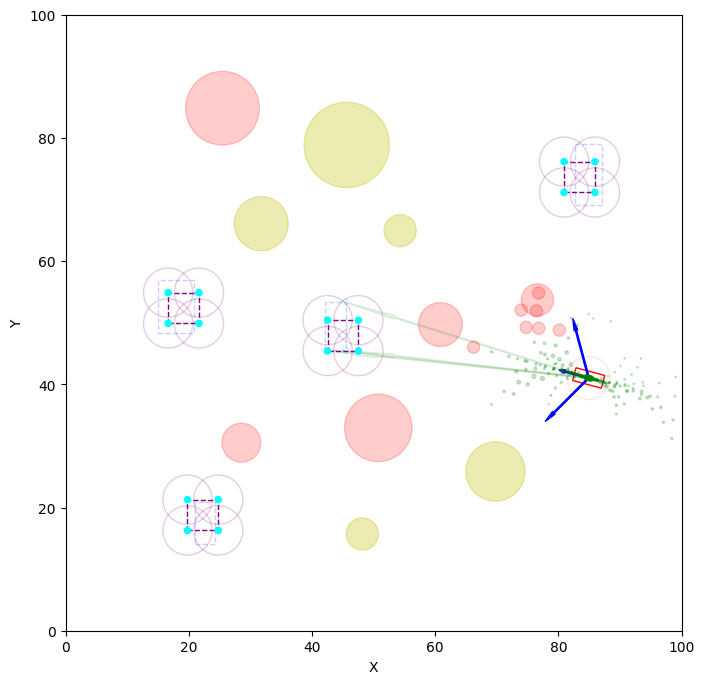

In [8]:
# Run search on the new subtree
start_time = timeit.default_timer()
new_subroot = mcts_with_rollout(starting_state, learning_iterations, explore_factor, discount_factor, rollout_method, start_with_root=subroot)
print("Time taken: ", timeit.default_timer() - start_time)

# Display the tree and state
render_pyvis(new_subroot, env.action_space, show_unsimulated=False, filename='tree_reuse_with_search')
env.draw_state(starting_state, root_node=root, scaling=4, bias=0.1, max=1., rew=True)

In [11]:
num_actions = 2
state = deepcopy(starting_state)
states = [state]
rewards = []
roots = []
root = None
start_time = timeit.default_timer()
for i in range(num_actions):
    print(f'Action {i + 1}/{num_actions}')
    root = mcts_with_rollout(state, learning_iterations, explore_factor, discount_factor, rollout_method, start_with_root=root)
    best_child = root.children[root.best_child()]
    best_action = best_child.action
    state, reward, done = best_child.state, best_child.reward, best_child.done
    if done:
        print('Terminal state reached after action', i)
        break
    # state = (state[0], state[1], state[2], 0) # Reset horizon step back to 0 for next search
    states.append(state)
    rewards.append(reward)
    roots.append(root)
    
    render_pyvis(root, env.action_space, show_unsimulated=False, filename=f'tree_reuse_with_search_{i}')
    root = get_action_subtree(root, best_action)
    
    
comp_time = round(timeit.default_timer() - start_time, 2)
title = f'{num_actions} MCTS searches in {comp_time} seconds\n\
LI={learning_iterations}, EF={explore_factor}, DF={discount_factor}, HL={env.horizon_length}, RL={rollout_method}'
print(f'Done in {comp_time} seconds')

print('Creating state set visualization...')
env.draw_state_set(states, title_perm=title, rewards=rewards,
                   roots=roots, scaling=4, bias=0.1, max=1., rew=True)

Action 1/2


/home/austin/MeasurementMCTS/src/measurement_mcts/measurement_mcts/mcts/mcts.py:221: RuntimeWarning: divide by zero encountered in log
  * np.sqrt(np.log(self.number_visits)


Action 2/2
Done in 0.82 seconds
Creating state set visualization...


In [9]:
# Load metrics dataframe from data folder
df = pd.read_csv('data/metrics.csv')
df.head()

,strategy,percent done,actions,total reward,avg reward,LI,EF,DF,HL,dt,comp time,comp per action
0,One LI per action w/ rollout to horizon,90.949232,149,4.142909,0.027619,25,100,1.0,6,0.6,430.42,2.869467
1,One LI per action w/ rollout to horizon,69.650388,149,7.178495,0.047857,25,100,1.0,6,0.6,502.08,3.347200


In [8]:
new_df = pd.DataFrame(
[{'strategy': 'One LI per action w/ rollout to horizon', 
'percent done': get_percent_done(state, env),
'actions': i, 'total reward': sum(rewards),
'avg reward': sum(rewards) / len(rewards),
'LI': learning_iterations,
'EF': explore_factor,
'DF': discount_factor,
'HL': env.horizon_length,
'dt': env.simulation_dt,
'comp time': comp_time,
'comp per action': comp_time / num_actions,
}])

df = pd.concat([df, new_df], ignore_index=True)
df.head()

NameError: name 'state' is not defined

In [16]:
# Save dataframe to data folder
df.to_csv('data/metrics.csv', index=False)

In [1]:
def get_percent_done(state, env):
    # First calculate total trace at start
    total_trace = env.init_covariance_trace * env.num_oois
    
    df = state[1]
    df_ooi = df[df['object_type'] == 'ooi']
    covariances = np.vstack((df_ooi['covariances']))
    
    sum_trace = 0
    for cov in covariances:
        sum_trace += np.trace(cov)
    
    return (1 - sum_trace / total_trace) * 100
    
get_percent_done(starting_state, env)

NameError: name 'starting_state' is not defined

In [46]:
8 * 2 * 4 * 4

256

In [9]:
env.init_covariance_diag * 4 * 2 * 4

256.0